# More Xarray: Understanding Climatology Through Precipitation Data

This tutorial is adapted from the excellent materials of the [Climate Match Academy](https://comptools.climatematch.io/tutorials/W1D3_RemoteSensing/student/W1D3_Tutorial4.html) that provides a comprehensive introduction to computational tools in climate science. 

##  Tutorial Objectives

In this tutorial, you will explore the concept of a climatology, and learn how to leverage it using satellite precipitation data. Typically you would want your data to span at least 30 years to calculate a climatology to account for random year-to-year variability. Here you will use data spanning several decades to explore the seasonal cycle of precipitation at a specific location.

## Climate and Conceptional Skills

Upon completing this tutorial, you'll be able to:

- Comprehend the fundamentals of climatologies.
- Compute a climatology utilizing long-term satellite precipitation data.
- Create informative maps including features such as projections, coastlines, and other advanced plotting components.
* Calculate an anomaly to a climatology.
* Calculate the rolling mean of the anomaly data to smooth the time series and extract long-term signals/patterns.

Throughout this tutorial, you'll employ NOAA's monthly precipitation climate data records as the primary resource to demonstrate the process of calculating a long-term climatology for climate analysis. Specifically, you'll use the [Global Precipitation Climatology Project (GPCP) Monthly Precipitation Climate Data Record (CDR)](https://www.ncei.noaa.gov/products/climate-data-records/precipitation-gpcp-monthly). As part of your investigation, you'll focus on a specific location, observing its data across the entire time duration covered by the GPCP monthly dataset.

## Technical Skills 

This tutorial is also intended to further practice data analysis with python and Xarray. 

Upon completing this tutorial, you'll be able to:

- Retrieve files using `pooch` to ensure reproducibility
- Access climate data through an API from `AWS`
- Load and subset data from `netCDF` files using Xarray.
- Practice making and refining maps using Xarrays plotting functions.
- Apply Xarray grouping operations including `.groupby()`, `.rolling()`

### Importing libraries

For this tutorial we need a number of libraries. You have already encountered many of these before. Additionally, there are a couple of new libraries. 

*s3fs*, *boto3*, and *botocore* are libraries that help python interface with Amazon AWS, where the climate data that we will be working with is stored. 

*pooch*: [Pooch](https://pypi.org/project/pooch/)^[because it fetches your data] is a Python library that can manage data by downloading files from a server (only when needed) and storing them locally in a data cache (a folder on your computer). This allows you to integrate the download of your data into your data pipelines making them more reproducible. *pooch* also creates a unique signature (a *hash*) for each downloaded file. If a file changes the _hash_ will be different, so that you know when the underlying data is changed. 

In [15]:
# system libraries that we will use
import os
import tempfile
# you already know these
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
# new libraries 
import pooch 
import s3fs
import boto3
import botocore


## Section 1: Obtain Monthly Precipitation Data

In this tutorial, the objective is to demonstrate how to calculate the long-term precipitation climatology using monthly precipitation climate data records from NOAA. 

You'll be utilizing the [Global Precipitation Climatology Project (GPCP) Monthly Precipitation Climate Data Record (CDR)](https://www.ncei.noaa.gov/products/climate-data-records/precipitation-gpcp-monthly). This dataset contains monthly satellite-gauge data and corresponding precipitation error estimates from January 1979 to the present, gridded at a 2.5°×2.5° resolution. *Satellite-gauge* means that the climate data record (CDR) is a compilation of precipitation data from multiple satellites and in-situ sources, combined into a final product that optimizes the advantages of each type of data.

While a higher spatial resolution (1°×1°) at daily resolution exists for varied applications, we will restrict ourselves to the coarser resolution monthly data due to computational limitations. However, you are encouraged to delve into the daily higher resolution data for your specific project needs.

### Section 1.1: Access GPCP Monthly CDR Data on AWS

All the National Atmospheric and Oceanic Administration Climate Data Record (NOAA-CDR) datasets are available both at NOAA National Centers for Environmental Information (NCEI) and commercial cloud platforms. Here, we are accessing the data directly via the Amazon Web Service (AWS). You can get more information about the NOAA CDRs on AWS’s Open Data Registry.

- [NOAA Fundamental CDR on AWS](https://registry.opendata.aws/noaa-cdr-fundamental/)
- [NOAA Terrestrial CDR on AWS](https://registry.opendata.aws/noaa-cdr-terrestrial/)
- [NOAA Atmospheric CDR on AWS](https://registry.opendata.aws/noaa-cdr-atmospheric/)
- [NOAA Oceanic CDR on AWS](https://registry.opendata.aws/noaa-cdr-oceanic/)


To perform analysis, we will need to access the monthly data files from AWS first. 

Using `s3fs`, we can browse the AWS filesystem (also called S3 buckets). 


In [20]:
# connect to the AWS S3 bucket for the GPCP Monthly Precipitation CDR data
fs = s3fs.S3FileSystem(anon=True)

# get the list of all data files in the AWS S3 bucket fit the data file pattern.
file_pattern = "noaa-cdr-precip-gpcp-monthly-pds/data/*/gpcp_v02r03_monthly_*.nc"
file_location = fs.glob(file_pattern)
file_location#[0:3]

['noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197901_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197902_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197903_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197904_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197905_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197906_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197907_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197908_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197909_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197910_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-pds/data/1979/gpcp_v02r03_monthly_d197911_c20170616.nc',
 'noaa-cdr-precip-gpcp-monthly-p

We can see that files are organized in a clear pattern. Each data product is organized in a folder (`noaa-cdr-precip-gpcp-monthly-pds`). 

Files are then organized by `year` into subfolders. 

The filenames themselves also have a pattern: 

> Product Name: `gpcp` (Global Precipitation Climatology Product)
>
> Version: `v02r03` (Version 2, Revision 3)
>
> Temporal resolution: `monthly`
>
> Date: `d<yyyymm>`
>
> Processing Time: `c20170616` (This will change for each file based on when the file was processed)
>
> File format: `.nc` (netCDF-4 format)

In other words, if we are looking for the data of a specific day, we can easily locate where the file might be.

For more on data on AWS see here: [https://comptools.climatematch.io/tutorials/W1D3_RemoteSensing/student/W1D3_Tutorial2.html](https://comptools.climatematch.io/tutorials/W1D3_RemoteSensing/student/W1D3_Tutorial2.html)

In [17]:
print("Total number of GPCP Monthly precipitation data files:")
print(len(file_location))

Total number of GPCP Monthly precipitation data files:
564


We have more than 500 GPCP monthly precipitation CDR data files in the AWS S3 bucket. Each data file contains the data of each month globally starting from January 1979. Now, let's open a single data file to look at the data structure before we open all data files.

In [18]:
# first, open a client connection
client = boto3.client(
    "s3", config=botocore.client.Config(signature_version=botocore.UNSIGNED)
)  # initialize aws s3 bucket client

# read single data file to understand the file structure
ds_single = xr.open_dataset(pooch.retrieve('http://s3.amazonaws.com/'+file_location[0],known_hash=None )) # open the file
ds_single.data_vars

Data variables:
    lat_bounds    (latitude, nv) float32 576B ...
    lon_bounds    (longitude, nv) float32 1kB ...
    time_bounds   (time, nv) datetime64[ns] 16B ...
    precip        (time, latitude, longitude) float32 41kB ...
    precip_error  (time, latitude, longitude) float32 41kB ...

From the information provided by `xarray`, there are a total of five data variables in this monthly data file, including `precip` for the monthly precipitation and `precip_error` for the monthly precipitation error.

In [19]:
ds_single.coords

Coordinates:
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * time       (time) datetime64[ns] 8B 1979-01-01

All data is organized in three dimensions: `latitude`, `longitude`, and `time`. We want to create a three-dimensional data array for the monthly precipitation data across the entire data period (from January 1979 until present) so we must open all the available files

In [7]:
file_ob = [pooch.retrieve('http://s3.amazonaws.com/'+file,known_hash=None ) for file in file_location]

SHA256 hash of downloaded file: d0836fb9f1bcbf8be09b946626c170ddd7764c0b6dc044d90d3a0ca5fbcb928e
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: 015433aca66f3a6f1a5df835b4d8707d71c8b4cd982d59d7465cebf629a86e1c
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: def01006f32b0b8760dde3320e39c68fd961c4df3afa0ccb8e25ecb474d74b7f
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: cd1ec680e7e2b6e659070a67c2cf763687182bad411d264e919b5c599330a015
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: ef9c

In [21]:
# using this function instead of 'open_dataset' will concatenate the data along the dimension we specify
#ds = xr.open_mfdataset(file_ob, combine="nested", concat_dim="time")

# comment for colab users only: this could toss an error message for you.
# you should still be able to use the dataset with this error just not print ds
# you can try uncommenting the following line to avoid the error
# ds.attrs['history']='' # the history attribute have unique chars that cause a crash on Google colab.
#ds

# I also downloaded the data and created a single nc file that is placed in the Data folder. We can use this if pooch takes too long. 
ds = xr.open_dataset('../Data/noaa_gpcp.nc')
ds

<xarray.Dataset> Size: 48MB
Dimensions:       (time: 564, latitude: 72, nv: 2, longitude: 144)
Coordinates:
  * time          (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
  * latitude      (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * longitude     (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
Dimensions without coordinates: nv
Data variables:
    lat_bounds    (time, latitude, nv) float32 325kB ...
    lon_bounds    (time, longitude, nv) float32 650kB ...
    time_bounds   (time, nv) datetime64[ns] 9kB ...
    precip        (time, latitude, longitude) float32 23MB ...
    precip_error  (time, latitude, longitude) float32 23MB ...
Attributes: (12/45)
    Conventions:                CF-1.6, ACDD 1.3
    title:                      Global Precipitation Climatatology Project (G...
    source:                     oc.197901.sg
    references:                 Huffman et al. 1997, http://dx.doi.org/10.117...
    history:                    1) �R
`�, Dr. Jian-Jian Wang, U of Maryland,...
    Metadata_Conventions:       CF-1.6, Unidata Dataset Discovery v1.0, NOAA ...
    ...                         ...
    metadata_link:              gov.noaa.ncdc:C00979
    product_version:            v23rB1
    platform:                   NOAA POES (Polar Orbiting Environmental Satel...
    sensor:                     AVHRR>Advanced Very High Resolution Radiometer
    spatial_resolution:         2.5 degree
    comment:                    Processing computer: eagle2.umd.edu

In the above code, we used `combine='nested', concat_dim='time'` to combine all monthly precipitation data into one data array along the dimension of `time`. This command is very useful when reading in multiple data files of the same structure but covering different parts of the full data record.

Since we are interested in the precipitation data globally at this moment, let's extract the entire data array of precipitation from the entire dataset.

In [22]:
# examine the precipitation data variable
precip = ds.precip
precip

<xarray.DataArray 'precip' (time: 564, latitude: 72, longitude: 144)> Size: 23MB
[5847552 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
Attributes:
    long_name:      NOAA Climate Data Record (CDR) of GPCP Monthly Satellite-...
    standard_name:  precipitation amount
    units:          mm/day
    valid_range:    [  0. 100.]
    cell_methods:   area: mean time: mean

As you can see, the data array has the dimensions of `time` `longitude` `latitude`. Before delving into further analysis, let's visualize the precipitation data to gain a better understanding of its patterns and characteristics. 

### Section 1.2: Visualize GPCP Data Using Cartopy
In previous tutorials, we've learned how to make simple visualization using `matplotlib` using `latitude` and `longitude` as the y-axis and x-axis.

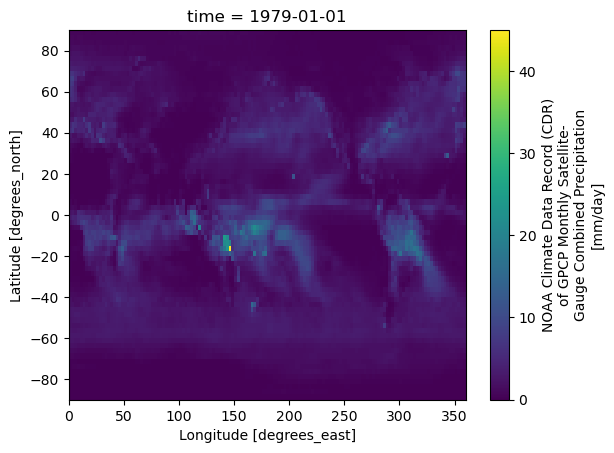

In [23]:
# create simple map of the GPCP precipitation data using matplotlib
fig, ax = plt.subplots()

# use the first month of data as an example
precip.sel(time="1979-01-01").plot(ax=ax)

From the figure, the boundary between land and ocean, especially for North and South America, can be observed vaguely. However, this visualization is not ideal as it requires some guesswork in identifying the specific regions. To overcome this limitation and enhance the visualization, we will employ `cartopy`, a library that offers advanced mapping features. With `cartopy`, we can incorporate additional elements such as coastlines, major grid markings, and specific map projections.

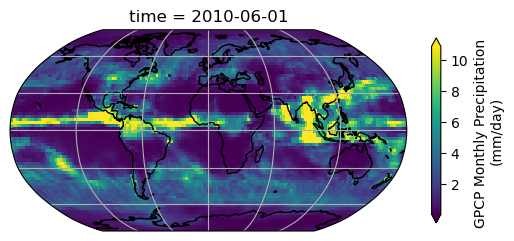

In [25]:
# visualize the precipitation data of a selected month using cartopy

# select data for the month of interest
data = precip.sel(time="2010-06-01", method="nearest")

# initiate plot, note that it is possible to change the size of the figure,
# which is already defined within the "cma.mplstyle" file in the 'Figure Settings' cell above
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Robinson()},
                       #figsize=(9, 6)
                      )

# add coastlines to indicate land/ocean
ax.coastlines()

# add major grid lines for latitude and longitude
ax.gridlines()

# add the precipitation data with map projection transformation
# also specify the maximum 'vmax' and minimum value 'vmin' or set 'robust=True' to increase the
# contrast in the map.
data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    #vmin=0,
    #vmax=20,
    robust=True,
    cbar_kwargs=dict(shrink=0.5, label="GPCP Monthly Precipitation \n(mm/day)"), # this controls the colorbar appearance
)

The updated map provides significant improvements, offering us a wealth of information to enhance our understanding of the GPCP monthly precipitation data. From the visualization, we can observe that regions such as the Amazon rainforest, the northern part of Australia, and other tropical areas exhibited higher levels of monthly precipitation in January 1979. These patterns align with our basic geographical knowledge, reinforcing the validity of the data and representation.

### Coding Exercises 1.2
Remember the GPCP also offers a data variable that documents the error of the monthly precipitation data used above. This error information is valuable for understanding the level of confidence we can place on the data. 

1. Generate the precipitation error for the same month (1979-01-01) using the examples provided above.

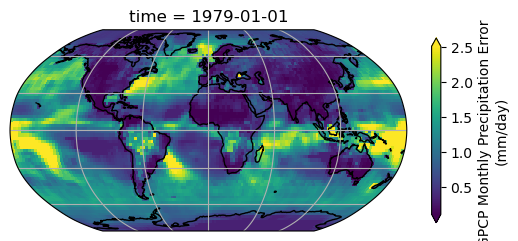

In [31]:
# select data for the month of interest
data = ds.precip_error.sel(time="1979-01-01", method="nearest")
#ds.precip_error.sel(time="1979-01-01", method="nearest")

# initiate plot
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Robinson()})

# add coastlines to indicate land/ocean
ax.coastlines()

# add major grid lines for latitude and longitude
ax.gridlines()

# add the precipitation data
data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    #vmin=0,
    #vmax=20,
    robust=True,
    cbar_kwargs=dict(shrink=0.5, label="GPCP Monthly Precipitation Error \n(mm/day)"), # this controls the colorbar appearance
)

[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D3_RemoteSensing/solutions/W1D3_Tutorial4_Solution_8041e1ae.py)

### Questions 1.2: Climate Connection
1. Comment on the spatial pattern of the precipitation error provided by GPCP CDR data for this specific month. 
2. Which areas have the highest errors? Why do you think this might be?

## Section 2: Climatology

## Section 2.1: Plot Time Series of Data at a Specific Location

We have over 40 years of monthly precipitation data. Let's examine a specific location throughout the entire time span covered by the GPCP monthly data. For this purpose, we will focus on the data point located at (0°N, 0°E).

Text(0, 0.5, 'GPCP Monthly Precipitation \n(mm/day)')

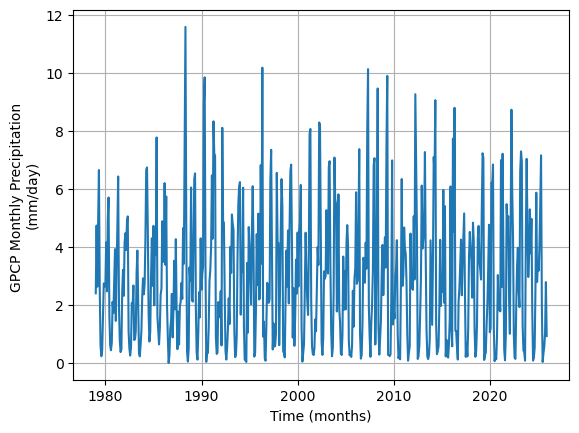

In [33]:
# select the entire time series for the grid that contains the location of (0N, 0E)
grid = ds.precip.sel(latitude=0, longitude=0, method="nearest")

# initiate plot
fig, ax = plt.subplots()

# plot the data
grid.plot(ax=ax)

# remove the automatically generated title
ax.set_title("")

# add a grid
ax.grid(True)

# edit default axis labels
ax.set_xlabel("Time (months)")
ax.set_ylabel("GPCP Monthly Precipitation \n(mm/day)")

From the time series plot, note a repeating pattern with a seasonal cycle (roughly the same ups and downs over the course of a year, for each year). In previous tutorials during the climate system overview, you learned how to calculate a climatology. We can apply this same calculation to the precipitation CDR data to investigate the annual cycle of precipitation at this location.

## Section 2.2: Calculate the Climatology

As a refresher, a climatology typically employs a 30-year time period for the calculation. In this case, let's use the reference period of 1981-2010.

In [34]:
# first, let's extract the data for the time period that we want (1981-2010)
precip_30yr = ds.precip.sel(time=slice("1981-01-01", "2010-12-30"))
precip_30yr

<xarray.DataArray 'precip' (time: 360, latitude: 72, longitude: 144)> Size: 15MB
[3732480 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 3kB 1981-01-01 1981-02-01 ... 2010-12-01
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
Attributes:
    long_name:      NOAA Climate Data Record (CDR) of GPCP Monthly Satellite-...
    standard_name:  precipitation amount
    units:          mm/day
    valid_range:    [  0. 100.]
    cell_methods:   area: mean time: mean

Now we can use Xarray's [`.groupby()`](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.groupby.html) functionality to calculate the monthly climatology.

Recall that `.groupby()` splits the data based on a specific criterion (in this case, the month of the year) and then applies a process (in our case, calculating the mean value across 30 years for that specific month) to each group before recombining the data together.

In [35]:
# use .groupby() to calculate monthly climatology (1981-2010)
precip_clim = precip_30yr.groupby("time.month").mean(dim="time")
precip_clim

<xarray.DataArray 'precip' (month: 12, latitude: 72, longitude: 144)> Size: 498kB
array([[[0.02121412, 0.03455903, 0.03909743, ..., 0.03031545,
         0.02503954, 0.01767228],
        [0.01468335, 0.01513875, 0.01926829, ..., 0.02597013,
         0.02376271, 0.02005625],
        [0.01786943, 0.01843644, 0.02427593, ..., 0.03049185,
         0.02576967, 0.02052885],
        ...,
        [0.5835213 , 0.5631948 , 0.54983175, ..., 0.5684174 ,
         0.5357807 , 0.5660979 ],
        [0.46609816, 0.48883978, 0.4570602 , ..., 0.43442884,
         0.46374935, 0.47652802],
        [0.45937675, 0.41984814, 0.43341768, ..., 0.43685257,
         0.42299047, 0.4576313 ]],

       [[0.07515567, 0.06536706, 0.08534641, ..., 0.03901516,
         0.06351497, 0.06464184],
        [0.05553975, 0.05907081, 0.05703541, ..., 0.04810192,
         0.0413678 , 0.06097476],
        [0.07742124, 0.09297629, 0.07022998, ..., 0.08889688,
         0.08341079, 0.06982979],
...
        [0.6340751 , 0.6338255 , 0.6397692 , ..., 0.59909993,
         0.6136984 , 0.59109604],
        [0.4575287 , 0.48333123, 0.45927143, ..., 0.4564395 ,
         0.4406456 , 0.4584723 ],
        [0.34033284, 0.3482346 , 0.3382898 , ..., 0.36154476,
         0.3229496 , 0.3703981 ]],

       [[0.04853453, 0.05379036, 0.04518276, ..., 0.05228734,
         0.05038832, 0.04638784],
        [0.02877913, 0.03100508, 0.04096953, ..., 0.03839006,
         0.04987149, 0.04136991],
        [0.04602271, 0.04031755, 0.03350022, ..., 0.03906622,
         0.04838271, 0.04283136],
        ...,
        [0.55979794, 0.55533737, 0.5635692 , ..., 0.5456134 ,
         0.5387876 , 0.55500877],
        [0.43627548, 0.42571914, 0.42603523, ..., 0.47095472,
         0.42469752, 0.42800856],
        [0.38080624, 0.35659346, 0.35415858, ..., 0.36278546,
         0.42218426, 0.3585709 ]]], shape=(12, 72, 144), dtype=float32)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
Attributes:
    long_name:      NOAA Climate Data Record (CDR) of GPCP Monthly Satellite-...
    standard_name:  precipitation amount
    units:          mm/day
    valid_range:    [  0. 100.]
    cell_methods:   area: mean time: mean

With the resulting climatology data array, we can make a set of maps to visualize the monthly climatology from four different seasons.

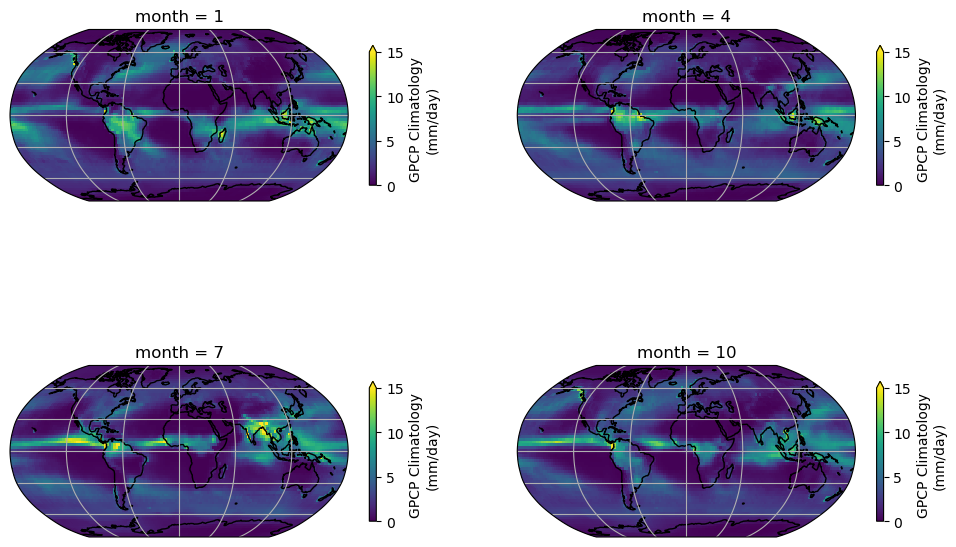

In [36]:
# define the figure and each axis for the 2 rows and 2 columns
fig, axs = plt.subplots(
    nrows=2, ncols=2, subplot_kw={"projection": ccrs.Robinson()}, figsize=(12, 8)
)

# axs is a 2-dimensional array of `GeoAxes`.  We will flatten it into a 1-D array to loop over it
axs = axs.flatten()

# loop over selected months (Jan, Apr, Jul, Oct)
for i, month in enumerate([1, 4, 7, 10]):

    # Draw the coastlines and major gridline for each subplot
    axs[i].coastlines()
    axs[i].gridlines()

    # Draw the precipitation data
    precip_clim.sel(month=month).plot(
        ax=axs[i],
        transform=ccrs.PlateCarree(),
        vmin=0,
        vmax=15,  # use the same range of max and min value
        cbar_kwargs=dict(shrink=0.5, label="GPCP Climatology\n(mm/day)"),
    )

In the seasonal collection of the climatology map, we can observe a clear pattern of precipitation across the globe. The tropics exhibit a higher amount of precipitation compared to other regions. Additionally, the map illustrates the seasonal patterns of precipitation changes across different regions of the globe, including areas influenced by monsoons.

Now let's examine the climatology of the location we previously analyzed throughout the entire time series, specifically at (0°N, 0°E).

Text(0, 0.5, 'GPCP Monthly Precipitation \n(mm/day)')

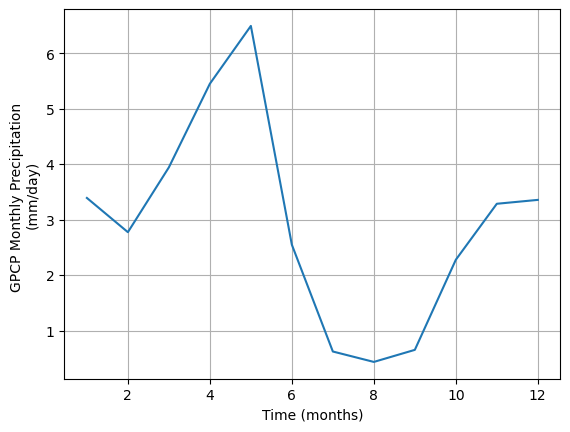

In [37]:
# initiate plot
fig, ax = plt.subplots()

# select location and add to plot
precip_clim.sel(latitude=0, longitude=0, method="nearest").plot(ax=ax)

# remove the automatically generated title
ax.set_title("")
# add a grid
ax.grid(True)
# edit default axis labels
ax.set_xlabel("Time (months)")
ax.set_ylabel("GPCP Monthly Precipitation \n(mm/day)")

#### Coding Exercises 2.2

As climate changes, the climatology of precipitation may also change. In fact, climate researchers recalculate a climatology every 10 years. This allows them to monitor how the norms of our climate system change. In this exercise, you will visualize how the climatology of our dataset changes depending on the reference period used.

1. Calculate the climatology for a different reference period (1991-2020) and compare it to the climatology that we just generated with the reference period (1981-2010). Be sure to compare the two and note the differences. Can you see why it is important to re-calculate this climatology?


In [ ]:
# extract 30 year data for 1991-2020
precip_30yr_exercise = ...

# calculate climatology for 1991-2020
precip_clim_exercise = ...

# find difference in climatologies: (1981-2010) minus (1991-2020)
precip_diff_exercise = ...

# Compare the climatology for four different seasons by generating the
#         difference maps for January, April, July, and October with colorbar max and min = 1,-1

# Define the figure and each axis for the 2 rows and 2 columns
fig, axs = plt.subplots(
    nrows=2, ncols=2, subplot_kw={"projection": ccrs.Robinson()}#, figsize=(12, 8)
)

# axs is a 2-dimensional array of `GeoAxes`. We will flatten it into a 1-D array
axs = ...

# Loop over selected months (Jan, Apr, Jul, Oct)
for i, month in enumerate([1, 4, 7, 10]):
    ...

SyntaxError: unmatched ')' (1628201329.py, line 27)

[*Click for solution*](https://github.com/neuromatch/climate-course-content/blob/main/tutorials/W1D3_RemoteSensing/solutions/W1D3_Tutorial4_Solution_f1c5c17b.py)

## Summary for calculating climatologies

Climatologies provide valuable insight into the typical weather patterns of a region. Key takeaways from this tutorial include:

- A climatology pertains to the long-term average of various system attributes, such as temperature and precipitation, often spanning 30 years.
- Satellite climate data records offer valuable insights for calculating climatologies on a global scale.

By comparing the weather conditions of a specific day or month to the climatology, we can determine the extent to which they deviate from the norm. This concept of comparing against the climatology, or the norm, will be the focus of our next tutorial - the anomaly!

## Section 3: From Climatology to Anomaly

Building upon your knowledge of climatology from the last tutorial, Tutorial 4, you will now calculate the anomalies from this climatology. An **anomaly**, in the context of climate studies, represents a departure from standard climatological conditions. For example, if the normal January temperature of the city that you live in is 10°C and the January temperature of this year is 15°C. We usually say the temperature anomaly of January this year is 5°C above normal/ the climatology. The anomaly is an essential tool in detecting changes in climate patterns and is frequently utilized in critical climate reports such as those generated by the [Intergovernmental Panel on Climate Change (IPCC)](https://www.ipcc.ch/).

To calculate an anomaly, we first establish a reference period, usually a 30-year window, to define our climatology. In this process, it is crucial to use high-quality data and aggregate it to the desired spatial resolution and temporal frequency, such as weekly or monthly. The anomaly is then determined by subtracting this long-term average from a given observation, thus creating a useful metric for further climate analysis such as trend analysis.

In this tutorial, we will employ the [GPCP monthly precipitation Climate Data Record (CDR)](https://disc.gsfc.nasa.gov/datasets/GPCPMON_3.2/summary) to compute a monthly anomaly time series. Furthermore, we will learn to calculate the rolling mean of the generated precipitation anomaly time series. This knowledge will be invaluable for our upcoming tutorial on climate variability.

## Section 3.1: Calculating the Monthly Anomaly

To calculate the anomaly, you first need to calculate the monthly climatology. We have already done this above using `.sel()` and `.groupby()`. 

Just to make sure, we repeat this here. Have a look at the code below to make sure that you understand each part of the command. 

In [41]:
# calculate climatology using `.sel()` and `.groupby()` directly.
precip_clim = (
    ds.precip.sel(time=slice("1981-01-01", "2010-12-01"))
    .groupby("time.month")
    .mean(dim="time")
)
precip_clim

<xarray.DataArray 'precip' (month: 12, latitude: 72, longitude: 144)> Size: 498kB
array([[[0.02121412, 0.03455903, 0.03909743, ..., 0.03031545,
         0.02503954, 0.01767228],
        [0.01468335, 0.01513875, 0.01926829, ..., 0.02597013,
         0.02376271, 0.02005625],
        [0.01786943, 0.01843644, 0.02427593, ..., 0.03049185,
         0.02576967, 0.02052885],
        ...,
        [0.5835213 , 0.5631948 , 0.54983175, ..., 0.5684174 ,
         0.5357807 , 0.5660979 ],
        [0.46609816, 0.48883978, 0.4570602 , ..., 0.43442884,
         0.46374935, 0.47652802],
        [0.45937675, 0.41984814, 0.43341768, ..., 0.43685257,
         0.42299047, 0.4576313 ]],

       [[0.07515567, 0.06536706, 0.08534641, ..., 0.03901516,
         0.06351497, 0.06464184],
        [0.05553975, 0.05907081, 0.05703541, ..., 0.04810192,
         0.0413678 , 0.06097476],
        [0.07742124, 0.09297629, 0.07022998, ..., 0.08889688,
         0.08341079, 0.06982979],
...
        [0.6340751 , 0.6338255 , 0.6397692 , ..., 0.59909993,
         0.6136984 , 0.59109604],
        [0.4575287 , 0.48333123, 0.45927143, ..., 0.4564395 ,
         0.4406456 , 0.4584723 ],
        [0.34033284, 0.3482346 , 0.3382898 , ..., 0.36154476,
         0.3229496 , 0.3703981 ]],

       [[0.04853453, 0.05379036, 0.04518276, ..., 0.05228734,
         0.05038832, 0.04638784],
        [0.02877913, 0.03100508, 0.04096953, ..., 0.03839006,
         0.04987149, 0.04136991],
        [0.04602271, 0.04031755, 0.03350022, ..., 0.03906622,
         0.04838271, 0.04283136],
        ...,
        [0.55979794, 0.55533737, 0.5635692 , ..., 0.5456134 ,
         0.5387876 , 0.55500877],
        [0.43627548, 0.42571914, 0.42603523, ..., 0.47095472,
         0.42469752, 0.42800856],
        [0.38080624, 0.35659346, 0.35415858, ..., 0.36278546,
         0.42218426, 0.3585709 ]]], shape=(12, 72, 144), dtype=float32)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
Attributes:
    long_name:      NOAA Climate Data Record (CDR) of GPCP Monthly Satellite-...
    standard_name:  precipitation amount
    units:          mm/day
    valid_range:    [  0. 100.]
    cell_methods:   area: mean time: mean

Now we have the monthly precipitation climatology. How can we calculate the monthly anomaly?

As we learned before - let's use `.groupby()` from `xarray`. We can split the entire time period based on the month of the year and then subtract the climatology of that specific month from the monthly value and recombine the value together.

In [42]:
# use `.groupby()` to calculate the monthly anomaly
precip_anom = ds.precip.groupby("time.month") - precip_clim
precip_anom

<xarray.DataArray 'precip' (time: 564, latitude: 72, longitude: 144)> Size: 23MB
array([[[-0.02121412, -0.03455903, -0.03909743, ..., -0.03031545,
         -0.02503954, -0.01767228],
        [-0.01468335, -0.01513875, -0.01926829, ..., -0.02597013,
         -0.02376271, -0.02005625],
        [-0.01786943, -0.01843644, -0.02427593, ..., -0.03049185,
         -0.02576967, -0.02052885],
        ...,
        [ 0.3977191 ,  0.3688233 ,  0.26397485, ...,  0.3477332 ,
          0.27608627,  0.3356306 ],
        [ 0.28387776,  0.28569958,  0.21373788, ...,  0.26011637,
          0.2760908 ,  0.28966036],
        [ 0.20209593,  0.15749758,  0.18408835, ...,  0.13596374,
          0.18291005,  0.25003707]],

       [[ 0.26142028,  0.25122786,  0.23912537, ...,  0.24571635,
          0.23252046,  0.23843956],
        [ 0.20161813,  0.22213964,  0.22612885, ...,  0.21129283,
          0.21262676,  0.21715768],
        [ 0.0051227 ,  0.01235647,  0.00884507, ...,  0.08695575,
          0.10879693,  0.03866701],
...
        [-0.41815317, -0.40980762, -0.40192634, ..., -0.38645422,
         -0.4063389 , -0.38097256],
        [-0.29101598, -0.31527922, -0.28807318, ..., -0.28791004,
         -0.27106047, -0.2890886 ],
        [-0.19766684, -0.20581344, -0.19688693, ..., -0.22667468,
         -0.18426181, -0.22866571]],

       [[-0.04777246, -0.05302829, -0.04442069, ..., -0.05076319,
         -0.04932141, -0.04562577],
        [-0.02877913, -0.03100508, -0.04096953, ..., -0.03839006,
         -0.04987149, -0.04136991],
        [-0.04517001, -0.03889639, -0.03209089, ..., -0.03583547,
         -0.04715757, -0.04207997],
        ...,
        [-0.16020882, -0.14197299, -0.1378437 , ..., -0.17472234,
         -0.17401254, -0.18858647],
        [-0.01190254, -0.00909334, -0.01675382, ..., -0.01323804,
          0.01615331,  0.00101197],
        [-0.09783429, -0.07950768, -0.08326083, ..., -0.07527253,
         -0.1385411 , -0.0755952 ]]], shape=(564, 72, 144), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
    month      (time) int64 5kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
Attributes:
    long_name:      NOAA Climate Data Record (CDR) of GPCP Monthly Satellite-...
    standard_name:  precipitation amount
    units:          mm/day
    valid_range:    [  0. 100.]
    cell_methods:   area: mean time: mean

You may have noticed that there is an additional coordinate in the anomaly dataset. The additional coordinate is `month` which is a direct outcome because of the `.groupby()` action we just performed.

If you want to save the data for future use, you can write the data out to a netCDF file using `.to_netcdf()`. It will automatically carry all the coordinates, dimensions, and relevant information into the netCDF file.

In [ ]:
# an example of how to export the GPCP monthly anomaly data comparing to the climatology period of 1981-2010.
# precip_anom.to_netcdf('../Data/gpcp-monthly-anomaly_1981-2010.nc')

## Section 3.2: Examining the Anomaly

First, let's take a look at the geospatial pattern of the monthly anomaly of a selected month – January of 1979.

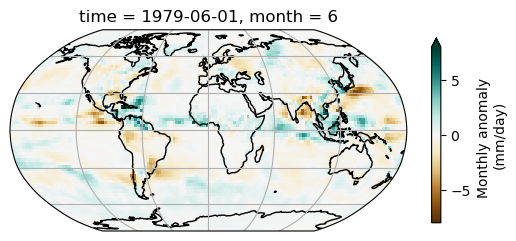

In [44]:
# initate plot
fig = plt.figure()

# set map projection
ax = plt.axes(projection=ccrs.Robinson())

# add coastal lines to indicate land/ocean
ax.coastlines()

# add grid lines for latitude and longitude
ax.gridlines()

# draw the precipitation data
precip_anom.sel(time="1979-06-01").plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=-8,
    vmax=8,
    cmap="BrBG",
    cbar_kwargs=dict(shrink=0.5, label="Monthly anomaly \n(mm/day)"),
)

To visualize the changes in the precipitation anomaly over many months, we can also take a look at the time series of a selected grid. We will use the same point (0°N, 0°E) that we used as an example in part 2.

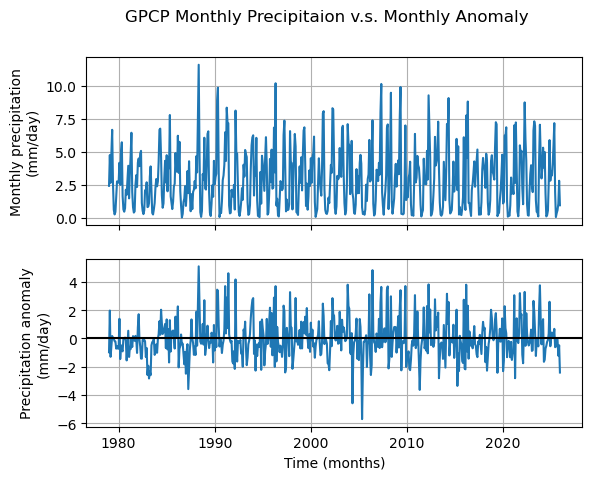

In [45]:
# set up two subplots that share the x-axis to compare monthly precipitation and monthly anomaly
fig, axs = plt.subplots(2, sharex=True)

# draw monthly precipitation
axs[0].plot(ds.time, ds.precip.sel(latitude=0, longitude=0, method="nearest"))

# set title and y-label
fig.suptitle("GPCP Monthly Precipitaion v.s. Monthly Anomaly")
axs[0].set_ylabel("Monthly precipitation\n(mm/day)")

# draw anomaly
axs[1].plot(
    precip_anom.time, precip_anom.sel(latitude=0, longitude=0, method="nearest")
)
# aesthetics
axs[1].set_xlabel("Time (months)")
axs[1].set_ylabel("Precipitation anomaly\n(mm/day)")

# add horizontal line of y=0 for the anomaly subplot
axs[1].axhline(y=0, color="k", linestyle="-")
# add grids
_ = [ax.grid(True) for ax in axs]

Note that, unlike the upper panel showing precipitation values, the lower panel displaying the monthly anomaly does not exhibit distinct seasonal cycles. This discrepancy highlights one of the advantages of utilizing anomaly data for climate analysis. By removing the repetitive patterns induced by seasonality or other stable factors, we can effectively isolate the specific signals in the data that are of interest, such as climate variability or climate trends. This approach allows for a clearer focus on the desired climate-related patterns without the interference of predictable seasonal variations.

## Section 4: Anomaly Analysis

In this section, we are going to explore a few different analyses of the anomaly data: 

- Calculating the rolling mean
- Calculating the global mean

You have already practiced using these tools during the last two days or material, here we will focus on applying them to a much longer satellite data record than you have encountered previously.

### Section 4.1: Rolling Mean

The monthly anomaly time series often contains noisy data that may obscure the patterns associated with large-scale climate variability. To mitigate this noise and enhance the visibility of underlying patterns, we can apply a rolling mean technique using the `.rolling()` method. This approach involves smoothing the monthly time series to facilitate the identification of climate variability.

In [46]:
# calculate 12-month rolling mean for the selected location, add in .compute() at the end if using Google Colab if it throws an error
grid_month = precip_anom.sel(latitude=0, longitude=0, method="nearest")
grid_rolling = grid_month.rolling(time=12, center=True).mean()

ValueError: (255, 2, 2) is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

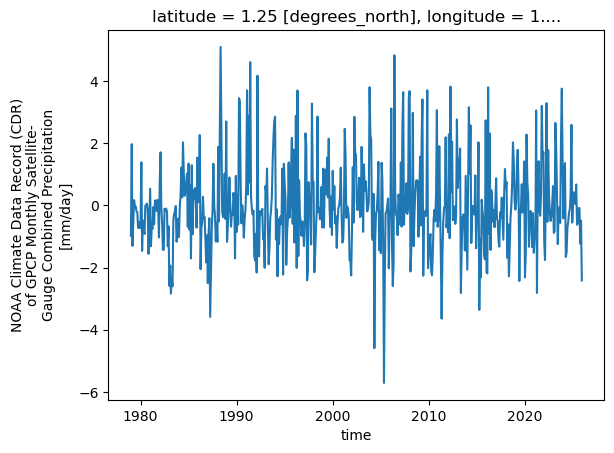

In [50]:
# create the time series plot of monthly anomaly
fig, ax = plt.subplots()
grid_month.plot(label="Monthly anomaly", ax=ax)
grid_rolling.plot(color='k', label="12-mon rolling mean", ax=ax)

# aesthetics
ax.axhline(y=0, color="y", linestyle="-")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Precipitation anomaly (mm/day)")
ax.legend()
ax.set_title("") # remove the automatically generated title
ax.grid(True)

As you can see, the 12-month rolling mean removes the high-frequency variations of monthly precipitation anomaly data, allowing the slower-changing patterns of precipitation to become more apparent.

### Coding Exercises 4.1

1. Calculate the 24-month rolling mean for the same grid and compare the three different time series (monthly anomaly, 12-month rolling mean, 24-month rolling mean).

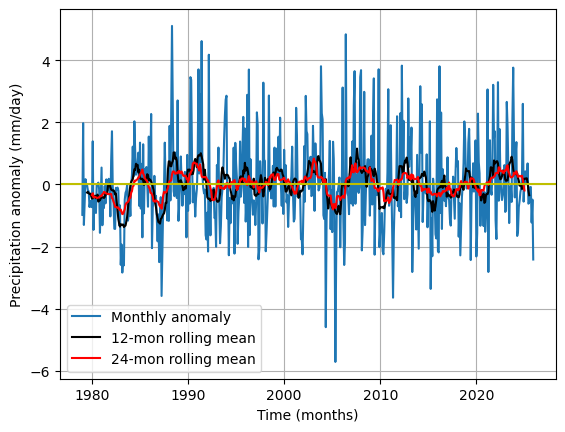

In [51]:
# calculate 24-month rolling mean
grid_rolling_24m =  grid_month.rolling(time=24, center=True).mean()

# plot all three time series together with different colors
fig, ax = plt.subplots()
_ = grid_month.plot(label="Monthly anomaly", ax=ax)
_ = grid_rolling.plot(color='k', label="12-mon rolling mean", ax=ax)
_ = grid_rolling_24m.plot(color='r', label="24-mon rolling mean", ax=ax)

# aesthetics
ax.axhline(y=0, color="y", linestyle="-")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Precipitation anomaly (mm/day)")
ax.legend()
ax.set_title("") # remove the automatically generated title
ax.grid(True)

[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D3_RemoteSensing/solutions/W1D3_Tutorial5_Solution_b9708e8c.py)

### Section 4.2: Global Mean

When examining global-scale changes, it is common to aggregate global mean values from all grid cells. However, it is important to note that despite each grid having the same resolution of `2.5°×2.5°`, they represent different areas on the Earth's surface. Specifically, the same grid covers larger spatial areas in the tropics compared to the polar regions as discussed in the climate system overview day (W1D1).

To address this issue, it is necessary to weigh the values based on their respective surface areas. Unlike the model data you used previously, where you had the grid cell area available as a variable, for our gridded observations we will use weights based on the cosine of the latitude as this function takes into account the decreasing area towards the poles.

In [53]:
# calculate the weights using the latitude coordinates
weights = np.cos(np.deg2rad(precip_anom.latitude))
weights.name = "weights"
weights
#precip_anom.mean()

<xarray.DataArray 'weights' (latitude: 72)> Size: 288B
array([0.02181496, 0.06540319, 0.10886693, 0.15212344, 0.19509035,
       0.23768592, 0.27982906, 0.32143947, 0.36243805, 0.4027467 ,
       0.4422887 , 0.48098874, 0.5187732 , 0.55557024, 0.59130967,
       0.62592345, 0.6593458 , 0.691513  , 0.72236395, 0.7518398 ,
       0.77988446, 0.8064446 , 0.8314696 , 0.85491186, 0.87672675,
       0.89687276, 0.91531146, 0.93200785, 0.9469301 , 0.96004987,
       0.9713421 , 0.98078525, 0.98836154, 0.99405634, 0.99785894,
       0.999762  , 0.999762  , 0.99785894, 0.99405634, 0.98836154,
       0.98078525, 0.9713421 , 0.96004987, 0.9469301 , 0.93200785,
       0.91531146, 0.89687276, 0.87672675, 0.85491186, 0.8314696 ,
       0.8064446 , 0.77988446, 0.7518398 , 0.72236395, 0.691513  ,
       0.6593458 , 0.62592345, 0.59130967, 0.55557024, 0.5187732 ,
       0.48098874, 0.4422887 , 0.4027467 , 0.36243805, 0.32143947,
       0.27982906, 0.23768592, 0.19509035, 0.15212344, 0.10886693,
       0.06540319, 0.02181496], dtype=float32)
Coordinates:
  * latitude  (latitude) float32 288B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
Attributes:
    long_name:      Latitude
    standard_name:  latitude
    units:          degrees_north
    valid_range:    [-90.  90.]
    axis:           Y
    bounds:         lat_bounds

Using the calculated `weights`, we can use xarray's [`.weighted()` method](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.weighted.html) to calculate a weighted mean. 

In [54]:
# calculate weighted global monthly mean
anom_weighted = precip_anom.weighted(weights)
global_weighted_mean = anom_weighted.mean(("latitude", "longitude"))
global_weighted_mean

<xarray.DataArray 'precip' (time: 564)> Size: 2kB
array([-4.78715310e-03,  4.00663503e-02, -3.66713828e-03, -1.99055187e-02,
       -4.04870287e-02, -1.56532426e-03, -4.75063846e-02, -3.03344335e-02,
        1.51366843e-02, -7.87217617e-02,  3.15483473e-02, -1.01841845e-01,
       -2.17346679e-02, -6.15173429e-02, -3.44578475e-02, -5.51472977e-02,
       -2.94865221e-02, -4.54375669e-02, -6.57088459e-02, -2.40857638e-02,
       -5.42311259e-02, -2.37260647e-02, -8.18650275e-02, -9.71601307e-02,
       -2.55893916e-03, -8.23690463e-03, -8.82864892e-02, -1.68188754e-02,
       -6.12774342e-02, -2.24509463e-02, -2.28423928e-03, -1.41724311e-02,
        1.69845279e-02,  4.64176899e-03,  5.16918935e-02,  2.29421705e-02,
        2.54556797e-02, -2.16429289e-02,  1.01031803e-01,  5.36163338e-02,
        2.34733261e-02,  3.20462659e-02, -3.04977465e-02,  7.99481496e-02,
       -1.91347878e-02, -1.52405975e-02,  1.15788830e-02,  5.96127436e-02,
       -1.46706775e-02, -2.06599552e-02, -5.46367578e-02, -4.27358113e-02,
       -3.55583685e-03,  3.44552137e-02,  3.40848528e-02,  4.26075682e-02,
        5.82496915e-03,  6.11081123e-02,  1.36923196e-03,  1.34506878e-02,
        2.62596179e-02,  3.25613394e-02, -4.76072542e-02,  1.08248666e-02,
        1.01503348e-02,  4.80577461e-02,  9.92247649e-03,  1.63122676e-02,
       -1.92289203e-02,  9.83044729e-02,  2.21571960e-02,  1.78565327e-02,
       -3.91630270e-02,  7.38672987e-02, -1.08189806e-02, -3.84190418e-02,
       -1.44688841e-02, -3.30092981e-02, -2.43040938e-02,  5.98275661e-02,
...
       -2.44919793e-03, -6.40302077e-02, -3.94416638e-02,  1.72562320e-02,
       -7.91842956e-03,  5.77329844e-02,  1.31387422e-02, -2.93645337e-02,
        5.55732511e-02, -2.06690766e-02, -1.87876318e-02, -3.74653526e-02,
       -1.12321088e-02,  1.02069508e-02, -5.19809946e-02, -1.13397948e-01,
       -7.01315030e-02, -6.03985079e-02, -7.11344481e-02, -1.00499734e-01,
        4.17943746e-02, -6.54074103e-02,  1.55770313e-02, -8.75429139e-02,
       -1.36517445e-02,  1.46244252e-02, -1.24515668e-01, -3.90001833e-02,
       -2.79403646e-02, -6.79166764e-02, -5.44156507e-03, -6.41971305e-02,
        5.93149615e-03, -5.68116941e-02,  1.77291129e-02, -7.22829625e-02,
        1.22923888e-02, -3.36115621e-02, -1.13284342e-01, -4.55126651e-02,
       -1.08419038e-01, -7.20836893e-02, -8.89458060e-02, -1.23525128e-01,
        4.32949932e-03,  2.45191865e-02,  2.46879011e-02, -2.05915561e-03,
        4.74666804e-02,  9.68679190e-02,  6.97383564e-03,  3.79010811e-02,
        3.76938060e-02,  5.50831035e-02,  6.90397099e-02,  1.88963208e-02,
        6.47103190e-02,  2.49455329e-02,  3.58131528e-02,  1.13426417e-03,
       -4.84240381e-03,  6.85824305e-02,  2.93890550e-03,  3.82293575e-02,
       -2.54867226e-02, -1.83787886e-02, -3.89338136e-02, -3.91420089e-02,
       -4.67586005e-03, -9.78491604e-02,  2.81113200e-03, -1.89418420e-02,
       -2.78159641e-02, -3.78772505e-02, -1.05483226e-01, -2.84202993e-02],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
    month    (time) int64 5kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:      NOAA Climate Data Record (CDR) of GPCP Monthly Satellite-...
    standard_name:  precipitation amount
    units:          mm/day
    valid_range:    [  0. 100.]
    cell_methods:   area: mean time: mean

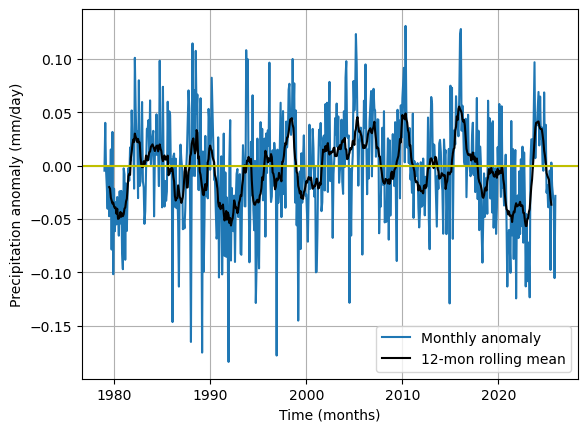

In [55]:
# create the time series plot of global weighted monthly anomaly
fig, ax = plt.subplots()
global_weighted_mean.plot(label="Monthly anomaly", ax=ax)
global_weighted_mean.rolling(time=12, center=True).mean(("latitude", "longitude")).plot(
    color="k", label="12-mon rolling mean", ax=ax
)
ax.axhline(y=0, color="y", linestyle="-")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Precipitation anomaly (mm/day)")
ax.legend()
ax.grid(True)

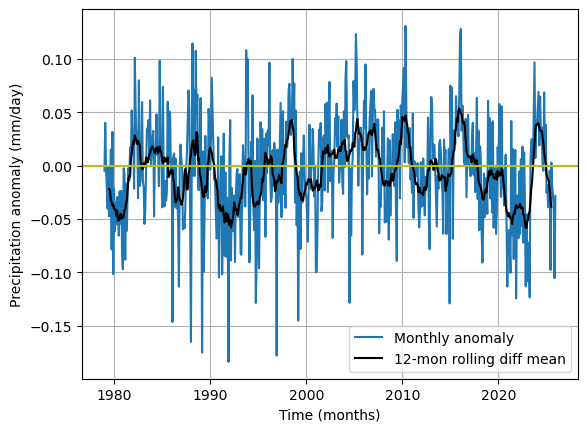

In [59]:
# calculate unweighted global mean
global_unweighted_mean = precip_anom.mean(("latitude", "longitude"))

# calculate the difference between weighted and unweighted global mean
global_diff = global_weighted_mean - precip_anom.mean()

# plot the time series of the difference
fig, ax = plt.subplots()
_ = global_weighted_mean.plot(label="Monthly anomaly", ax=ax)
_ =  global_diff.rolling(time=12, center=True).mean(("latitude", "longitude")).plot(
    color="k", label="12-mon rolling diff mean", ax=ax)

# aesthetics
ax.axhline(y=0, color="y", linestyle="-")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Precipitation anomaly (mm/day)")
ax.legend()
ax.grid(True)

[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D3_RemoteSensing/solutions/W1D3_Tutorial5_Solution_ddf4939d.py)


## Summary: Anomalies and weighted means

In this tutorial, you learned how to calculate a climate anomaly using satellite-derived precipitation data. 

* The anomaly allows us to look at the signals that may be covered by the seasonal cycle pattern (e.g., temperature/precipitation seasonal cycle).
* The anomaly data can be further smoothed using the rolling mean to reveal longer-term signals at an annual or decade time scale.

We will use the anomaly concept to study climate variability in the next tutorial.